Veri Setinin İlk 5 Satırı:


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen



Veri Seti Bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB

Sınıf Dağılımı (Kecimen / Besni):
Class
Kecimen    450
Besni      450
Name: count, dtype: int64

İstatistiksel Özet:


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


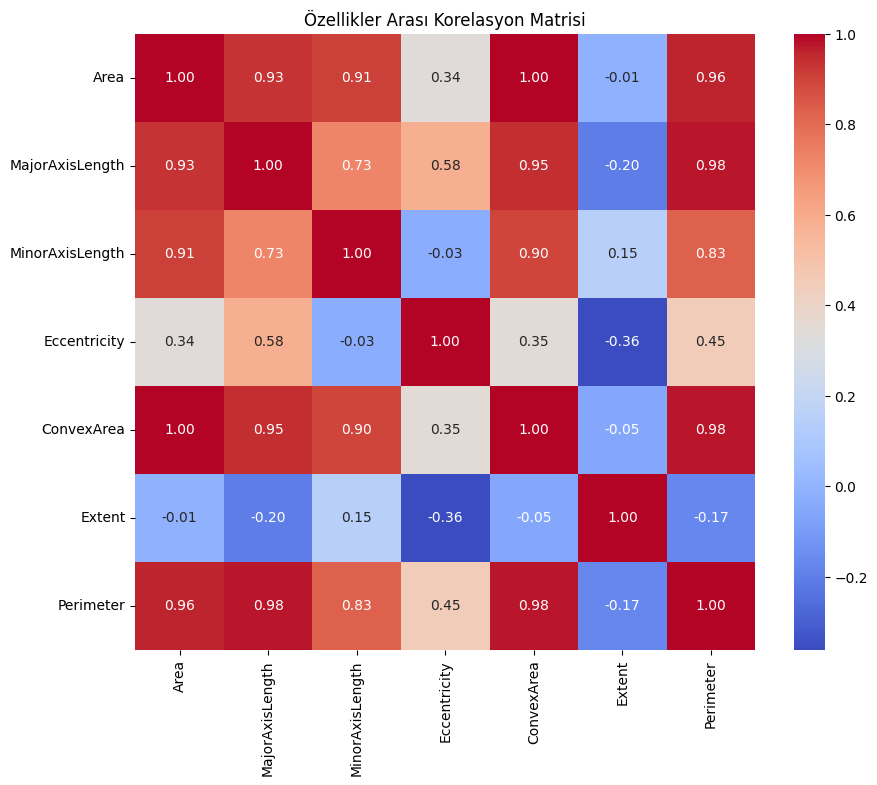

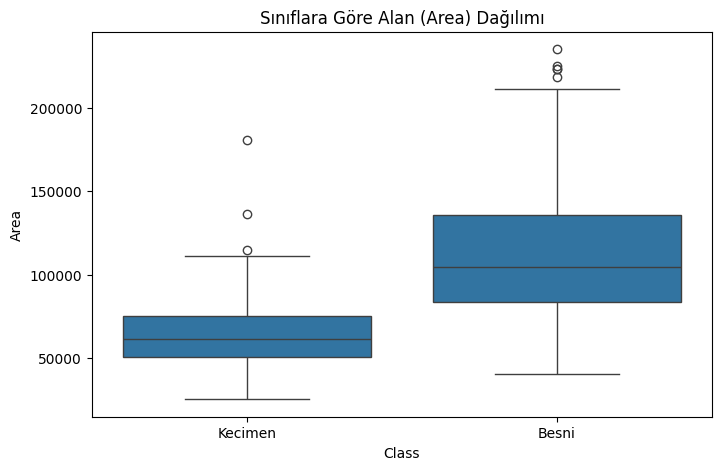

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veri Setini Yükleme
df = pd.read_excel('Raisin_Dataset.xlsx')

# 2. Genel Bakış
print("Veri Setinin İlk 5 Satırı:")
display(df.head())

print("\nVeri Seti Bilgileri:")
df.info()

print("\nSınıf Dağılımı (Kecimen / Besni):")
print(df['Class'].value_counts())

# 3. İstatistiksel İnceleme
print("\nİstatistiksel Özet:")
display(df.describe())

# 4. Korelasyon Matrisi (Hangi özellikler birbiriyle ilişkili?)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Özellikler Arası Korelasyon Matrisi")
plt.show()

# 5. Görselleştirme (Özelliklerin sınıflara göre dağılımı)
# Örnek olarak 'Area' özelliğini sınıflara göre kutu grafiği ile inceleyelim
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Area', data=df)
plt.title("Sınıflara Göre Alan (Area) Dağılımı")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Hedef ve Özelliklerin Ayrılması
X = df.drop('Class', axis=1) # 7 giriş değişkeni
y = df['Class']              # 1 çıkış değişkeni

# 2. Etiketleri Sayısal Hale Getirme (Kecimen=0, Besni=1)
le = LabelEncoder()
y = le.fit_transform(y)

# 3. Eğitim ve Test Setlerine Ayırma (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Ölçeklendirme (StandardScaler)
# Sadece eğitim setinden öğreniyoruz (fit), sonra her ikisine uyguluyoruz (transform)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Veri ön işleme tamamlandı!")
print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Veri ön işleme tamamlandı!
Eğitim seti boyutu: (720, 7)
Test seti boyutu: (180, 7)


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Modelin İskeletini Oluşturma
model = Sequential()

# Giriş Katmanı ve 1. Gizli Katman
# input_shape=(7,) çünkü 7 adet morfolojik özelliğimiz var.
model.add(Dense(16, input_shape=(7,), activation='relu'))

# 2. Gizli Katman (Modelin karmaşık desenleri öğrenmesini sağlar)
model.add(Dense(8, activation='relu'))

# Aşırı öğrenmeyi (Overfitting) önlemek için Dropout ekliyoruz
model.add(Dropout(0.2))

# Çıkış Katmanı (2 sınıflı olduğu için 1 nöron ve Sigmoid aktivasyonu)
model.add(Dense(1, activation='sigmoid'))

# 2. Modelin Derlenmesi (Compile)
# Adam optimizer
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Modelin özeti
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Eğitim süreci
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1, # Eğitim içinden %10'u doğrulama için ayırır
    verbose=1
)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4969 - loss: 0.7255 - val_accuracy: 0.5000 - val_loss: 0.6750
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6127 - loss: 0.6388 - val_accuracy: 0.7222 - val_loss: 0.6020
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7577 - loss: 0.5930 - val_accuracy: 0.8194 - val_loss: 0.5463
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8009 - loss: 0.5474 - val_accuracy: 0.8750 - val_loss: 0.5030
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8534 - loss: 0.5197 - val_accuracy: 0.9028 - val_loss: 0.4595
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8565 - loss: 0.4838 - val_accuracy: 0.8889 - val_loss: 0.4222
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8565 - loss: 0.4529 - val_accuracy: 0.8889 - val_loss: 0.3900
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8565 - loss: 0.4403 - val_accuracy: 0.8889 - v

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Classification Report:
              precision    recall  f1-score   support

     Kecimen       0.84      0.86      0.85        86
       Besni       0.87      0.85      0.86        94

    accuracy                           0.86       180
   macro avg       0.86      0.86      0.86       180
weighted avg       0.86      0.86      0.86       180



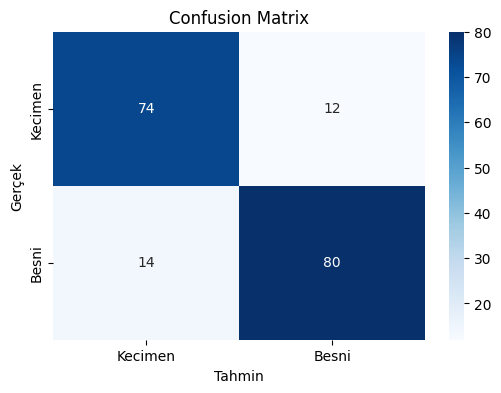

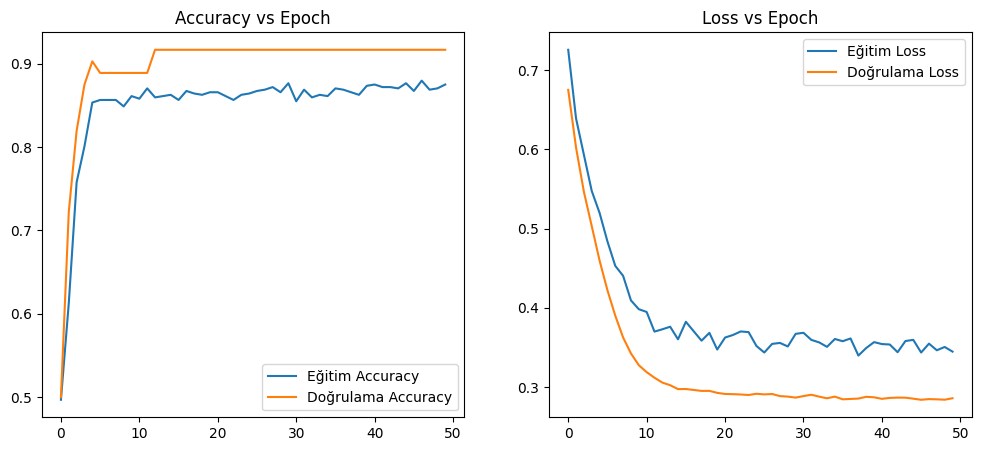

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tahminleri Al
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

# 2. Metrikleri Yazdır
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Kecimen', 'Besni']))

# 3. Confusion Matrix Görselleştirme
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Kecimen', 'Besni'], yticklabels=['Kecimen', 'Besni'])
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.title('Confusion Matrix')
plt.show()

# 4. Eğitim Grafiği (Loss ve Accuracy)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Accuracy')
plt.plot(history.history['val_accuracy'], label='Doğrulama Accuracy')
plt.legend()
plt.title('Accuracy vs Epoch')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Loss')
plt.plot(history.history['val_loss'], label='Doğrulama Loss')
plt.legend()
plt.title('Loss vs Epoch')
plt.show()